# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

This project aims to train a chess agent using reinforcement learning (PPO algorithm) and improve its chess skills through self-play. The agent's value head is initialized using a pre-trained evaluation network and then combined with a policy network for decision-making.

In [101]:
import os
import sys
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import chess
import chess.svg
import matplotlib.pyplot as plt
from collections import deque, Counter
from tqdm import tqdm
import pandas as pd
from itertools import product

In [102]:
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

使用设备: cpu


In [103]:
dataset_path = "../data/train.csv"
test_csv_path = "../data/test.csv"
sample_csv_path = "../data/sample_submission.csv"
test_chessData = pd.read_csv(test_csv_path)
sample_chessData = pd.read_csv(sample_csv_path)
chessData = pd.read_csv(dataset_path)

# 2. Initial Exploration

Basic information of the dataset

In [104]:
print(f"size of Dataset: {len(chessData)} row")
print(f"Columns: {chessData.columns.tolist()}")
print("\nNull value check:")
print(chessData.isnull().sum())


size of Dataset: 58785 行
Columns: ['id', 'board', 'black_score', 'best_move']

Null value check:
id             0
board          0
black_score    0
best_move      0
dtype: int64


Draw the histogram and kernel density estimation curve of the black square scores, and observe the distribution of the scores.

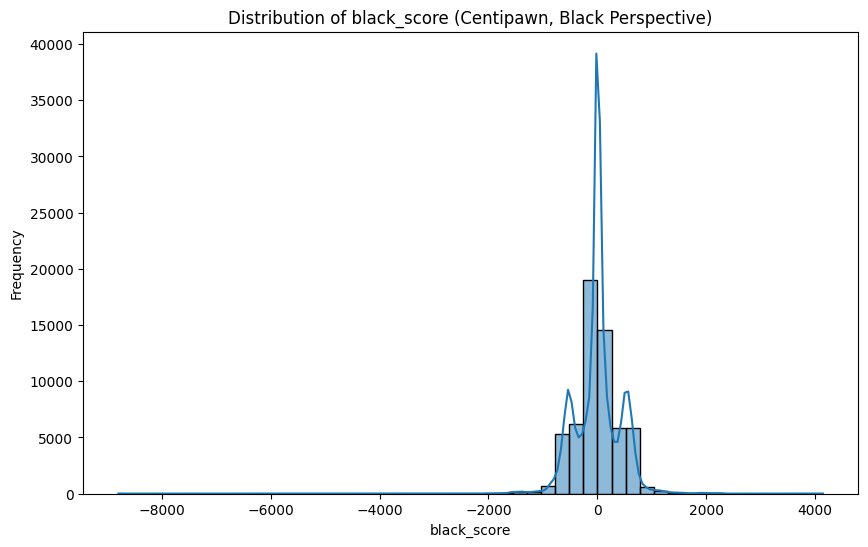

In [105]:
plt.figure(figsize=(10, 6))
sns.histplot(chessData['black_score'], bins=50, kde=True)
plt.title('Distribution of black_score (Centipawn, Black Perspective)')
plt.xlabel('black_score')
plt.ylabel('Frequency')
plt.show()

Count the occurrence frequency of each optimal move in the training set, and print the top 10 moves with the highest frequency of occurrence.

In [106]:
# Frequency statistics of the best moves
move_counter = Counter(chessData['best_move'])
print("\nTop 10 most common best moves:")
for move, count in move_counter.most_common(10):
    print(f"  {move}: {count}  ({count/len(chessData)*100:.2f}%)")


Top 10 most common best moves:
  d4d5: 325  (0.55%)
  d4e5: 317  (0.54%)
  d2d4: 316  (0.54%)
  c4d5: 316  (0.54%)
  c5d4: 299  (0.51%)
  d5e4: 290  (0.49%)
  b8c6: 289  (0.49%)
  e7e5: 273  (0.46%)
  a5a4: 271  (0.46%)
  f5e4: 267  (0.45%)


Randomly select one row of data, convert the chessboard state (FEN string) into a chess.Board object and print the chessboard, FEN, black player's score and the best move.

In [107]:
sample = chessData.sample(1).iloc[0]
board = chess.Board(sample['board'])
print("\nRandom sample board:")
print(board)
print(f"FEN: {sample['board']}")
print(f"Black score (centipawn): {sample['black_score']}")
print(f"Best move: {sample['best_move']}")


Random sample board:
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . K .
. . . . . . . .
. . . b . . . .
. B . . . . k .
FEN: 8/8/8/8/6K1/8/3b4/1B4k1 b - - 110 129
Black score (centipawn): 0.0
Best move: g1g2


# 3.Reinforcement learning environment and model definition

Define a chess reinforcement learning environment: reset the chessboard to its initial state. Make a move, returning the next state, reward, and whether the game is over. Calculate the reward (win/loss/draw) and termination flag based on the game-ending state. Calculate the difference in the total value of both players' pieces. Encode the chessboard state as a 12×8×8 tensor.

In [108]:
class ChessEnv:
    """Chess Reinforcement Learning Environment"""
    def __init__(self):
        self.board = chess.Board()
        
    def reset(self):
        self.board = chess.Board()
        return self._get_state()
    
    def step(self, action):
        move = chess.Move.from_uci(action)
        if move not in self.board.legal_moves:
            return self._get_state(), -1.0, True, {'illegal': True}
        
        self.board.push(move)
        reward, done = self._compute_reward_and_done()
        return self._get_state(), reward, done, {}
    
    def _compute_reward_and_done(self):
        """Calculate the reward and determine whether to terminate."""
        if self.board.is_checkmate():
            # Win reward: current player loses, previous player wins
            reward = 1.0 if self.board.turn == chess.WHITE else -1.0
            return reward, True
        elif self.board.is_stalemate() or self.board.is_insufficient_material():
            return 0.0, True
        else:
            # Material balance reward: encourage material advantage
            material = self._material_diff()
            # Encourage material advantage
            return 0.001 * material, False
    
    def _material_diff(self):
        white = black = 0
        values = {chess.PAWN:1, chess.KNIGHT:3, chess.BISHOP:3, chess.ROOK:5, chess.QUEEN:9}
        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            if piece:
                v = values.get(piece.piece_type, 0)
                if piece.color == chess.WHITE:
                    white += v
                else:
                    black += v
        return white - black
    
    def _get_state(self):
        tensor = np.zeros((12, 8, 8), dtype=np.float32)
        piece_to_channel = {
            chess.PAWN:0, chess.KNIGHT:1, chess.BISHOP:2,
            chess.ROOK:3, chess.QUEEN:4, chess.KING:5
        }
        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            if piece:
                row, col = divmod(square, 8)
                channel = piece_to_channel[piece.piece_type]
                if piece.color == chess.BLACK:
                    channel += 6
                tensor[channel, row, col] = 1.0
        return tensor

Define a dual-head neural network that simultaneously outputs a policy (movement probability) and a value (state evaluation). Shared convolutional layers extract chessboard features.

Policy Head: Outputs a 4096-dimensional vector representing all possible moves.

Value Head: Outputs a scalar between -1 and 1 (activated by the Tanh activation function).

In [109]:
class ChessNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(12, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2), nn.BatchNorm2d(128), nn.ReLU(),
        )
        
        # Strategy Head
        self.policy_conv = nn.Conv2d(128, 32, 3, padding=1)
        self.policy_fc = nn.Linear(32 * 3 * 3, 4096)
        
        # Value Head
        self.value_conv = nn.Conv2d(128, 32, 3, padding=1)
        self.value_fc = nn.Sequential(
            nn.Linear(32 * 3 * 3, 256),               # 修改此处：4*4 → 3*3
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.conv(x)
        
        # Strategy branch
        p = F.relu(self.policy_conv(x))
        p = p.view(p.size(0), -1)
        policy = self.policy_fc(p)
        
        # Value branch
        v = F.relu(self.value_conv(x))
        v = v.view(v.size(0), -1)
        value = self.value_fc(v)
        
        return policy, value

Implement a proxy for the PPO algorithm.

`action_to_idx` and `idx_to_action`: Establish a mapping between the move string (e.g., "e2e4") and the 4096-dimensional output index.

In [110]:
# -------------------- PPO Agent --------------------
class PPOAgent:
    def __init__(self, lr=3e-4, gamma=0.99, clip_epsilon=0.2, value_coef=0.5):
        self.net = ChessNet()
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.gamma = gamma
        self.clip_epsilon = clip_epsilon
        self.value_coef = value_coef
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.net.to(self.device)
        self.train_losses = []
        self.policy_entropies = []

        # Create a mapping from actions to indexes
        files = 'abcdefgh'
        self.action_to_idx = {}
        self.idx_to_action = {}
        idx = 0
        for f in range(8):
            for r in range(8):
                for t in range(8):
                    for tr in range(8):
                        action = f"{files[f]}{r+1}{files[t]}{tr+1}"
                        self.action_to_idx[action] = idx
                        self.idx_to_action[idx] = action
                        idx += 1
        assert len(self.action_to_idx) == 4096
    
    def get_action_probs(self, state, legal_moves):
        """The probability distribution of the legal actions to be returned"""
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            policy, _ = self.net(state_t)
            policy = F.softmax(policy, dim=-1).squeeze().cpu().numpy()

        probs = []
        for move in legal_moves:
            idx = self.action_to_idx.get(move.uci())
            if idx is not None:
                probs.append(policy[idx])
            else:
                probs.append(0.0)
        total = sum(probs)
        if total > 0:
            probs = [p / total for p in probs]
        else:
            probs = [1.0 / len(legal_moves)] * len(legal_moves)
        return np.array(probs)
    def _mask_illegal(self, probs, legal_moves):
        """Set the probability of illegal actions to 0 and re-normalize."""
        move_to_idx = {move: i for i, move in enumerate(sorted(legal_moves))}
        masked = np.zeros_like(probs)
        for move in legal_moves:
            idx = move_to_idx.get(move, 0)
            masked[idx] = probs[idx]
        total = masked.sum()
        if total > 0:
            masked /= total
        return masked
    def update(self, trajectories):
        """Update the network using PPO"""
        for states, actions, rewards in trajectories:
            # Calculate the discounted returns
            returns = []
            R = 0
            for r in reversed(rewards):
                R = r + self.gamma * R
                returns.insert(0, R)
            returns = np.array(returns)
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
            
            # Convert actions to indexes
            states_t = torch.FloatTensor(np.array(states)).to(self.device)
            returns_t = torch.FloatTensor(returns).to(self.device)
            
            # Convert actions to indexes
            policy, values = self.net(states_t)
            values = values.squeeze()
            policy = F.softmax(policy, dim=-1)
            # Calculate the loss
            value_loss = F.mse_loss(values, returns_t)
            loss = self.value_coef * value_loss
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            self.train_losses.append(loss.item())


The agent plays against itself to collect training data.

`epsilon`: An ε-greedy strategy that randomly selects moves with a certain probability to enhance its exploration capabilities.

`win_count`: Records the number of times White wins, Black wins, and draws.

In [111]:
def self_play(agent, env, num_games=10, epsilon=0.2):
    """Self-play games using the agent"""
    trajectories = []
    win_count = {'white':0, 'black':0, 'draw':0}
    
    for game in tqdm(range(num_games), desc=f"Self-play"):
        state = env.reset()
        states, actions, rewards = [], [], []
        done = False
        move_count = 0
        while not done and move_count < 200:
            legal_moves = list(env.board.legal_moves)
            probs = agent.get_action_probs(state, legal_moves)
            if random.random() < epsilon:
                action = random.choice(legal_moves).uci()
            else:
                try:
                    action = np.random.choice(legal_moves, p=probs).uci()
                except:
                    action = random.choice(legal_moves).uci()
            next_state, reward, done, _ = env.step(action)
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            state = next_state
            move_count += 1
        # Record the game result
        if env.board.is_checkmate():
            if env.board.turn == chess.WHITE:
                win_count['black'] += 1
            else:
                win_count['white'] += 1
        else:
            win_count['draw'] += 1
        
        trajectories.append((states, actions, rewards))
    
    return trajectories, win_count

In [112]:
# -------------------- Evaluate the agent --------------------
def evaluate_agent(agent, num_games=10, opponent='random'):
    """Evaluate the agent against a specified opponent"""
    env = ChessEnv()
    wins = 0
    draws = 0
    for _ in range(num_games):
        state = env.reset()
        done = False
        while not done:
            if env.board.turn == chess.WHITE:
                # The intelligent agent makes a move in the game.
                legal_moves = list(env.board.legal_moves)
                probs = agent.get_action_probs(state, legal_moves)
                action = legal_moves[np.argmax(probs)].uci()
            else:
                if opponent == 'random':
                    action = random.choice(list(env.board.legal_moves)).uci()
                else:
                    probs = agent.get_action_probs(state, legal_moves)
                    action = legal_moves[np.argmax(probs)].uci()
            next_state, reward, done, _ = env.step(action)
            state = next_state
        if env.board.is_checkmate():
            if env.board.turn == chess.WHITE:
                wins += 1
        elif env.board.is_stalemate():
            draws += 1
    return wins / (num_games - draws) if num_games > draws else 0, draws/num_games

In [113]:
# -------------------- Pretrain the value network with the dataset --------------------
def pretrain_with_dataset(model, dataset_path, batch_size=64, epochs=5):
    print("Loading dataset...")
    data = pd.read_csv(dataset_path)
    fens = data['board'].values
    scores = -data['black_score'].values
    score_mean, score_std = scores.mean(), scores.std()
    scores = (scores - score_mean) / (score_std + 1e-8)
    
    states = []
    for fen in tqdm(fens, desc="Encoding FEN"):
        env = ChessEnv()
        env.board = chess.Board(fen)
        state = env._get_state()
        states.append(state)
    states = np.array(states)
    dataset = TensorDataset(torch.FloatTensor(states), torch.FloatTensor(scores))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for batch_x, batch_y in tqdm(loader, desc=f"Epoch {epoch+1}"):
            device = next(model.parameters()).device
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            _, value = model(batch_x)
            loss = criterion(value.squeeze(), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
        print(f"Pretrain epoch {epoch+1}: loss={avg_loss:.4f}")
    return losses


# 4. Model training and evaluation

开始预训练...
Loading dataset...


Epoch 1: 100%|██████████| 919/919 [00:09<00:00, 94.50it/s] 


Pretrain epoch 1: loss=0.6910


Epoch 2: 100%|██████████| 919/919 [00:12<00:00, 76.16it/s]


Pretrain epoch 2: loss=0.5009


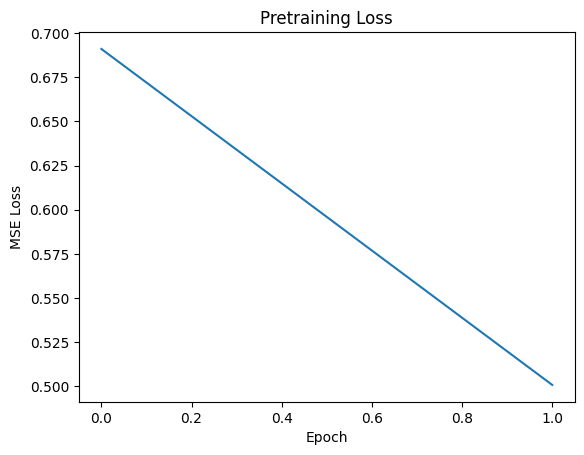

In [114]:
agent = PPOAgent(lr=3e-4)
env = ChessEnv()

print("Pretraining the value network with the dataset...")
losses = pretrain_with_dataset(agent.net, dataset_path, epochs=2, batch_size=64)
plt.plot(losses)
plt.title("Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [116]:
total_iterations = 25
games_per_iter = 10
eval_every = 5

win_rates = []
draw_rates = []

for iteration in range(total_iterations):
    # self-play
    epsilon = max(0.1, 0.5 - iteration/100)
    trajectories, win_count = self_play(agent, env, num_games=games_per_iter, epsilon=epsilon)
    
    # train the agent
    agent.update(trajectories)
    
    # evaluate the agent
    print(f"\n=== Iteration {iteration+1}/{total_iterations} ===")
    print(f"Self-play: White wins={win_count['white']}, Black wins={win_count['black']}, Draws={win_count['draw']}")
    
    # evaluate the agent against a random player
    if (iteration+1) % eval_every == 0:
        win_rate, draw_rate = evaluate_agent(agent, num_games=8, opponent='random')
        win_rates.append(win_rate)
        draw_rates.append(draw_rate)
        print(f"Evaluation vs random: Win rate={win_rate:.2f}, Draw rate={draw_rate:.2f}")
    
    
    if len(agent.train_losses) > 0:
        print(f"Latest loss: {agent.train_losses[-1]:.4f}")

# evaluate the agent against a random player
final_win, final_draw = evaluate_agent(agent, num_games=12)
print(f"\nFinal vs random: Win={final_win:.2f}, Draw={final_draw:.2f}")

Self-play: 100%|██████████| 10/10 [00:01<00:00,  7.98it/s]



=== Iteration 1/25 ===
Self-play: White wins=0, Black wins=0, Draws=10
Latest loss: 0.4892


Self-play: 100%|██████████| 10/10 [00:01<00:00,  8.23it/s]



=== Iteration 2/25 ===
Self-play: White wins=0, Black wins=0, Draws=10
Latest loss: 0.4766


Self-play: 100%|██████████| 10/10 [00:01<00:00,  9.80it/s]


...


=== Iteration 23/25 ===
Self-play: White wins=2, Black wins=1, Draws=7
Latest loss: 0.5175


Self-play: 100%|██████████| 10/10 [00:01<00:00,  6.81it/s]



=== Iteration 24/25 ===
Self-play: White wins=0, Black wins=0, Draws=10
Latest loss: 0.5136


Self-play: 100%|██████████| 10/10 [00:01<00:00,  7.34it/s]



=== Iteration 25/25 ===
Self-play: White wins=0, Black wins=1, Draws=9
Evaluation vs random: Win rate=0.00, Draw rate=0.25
Latest loss: 0.4701

Final vs random: Win=0.18, Draw=0.08
